#  Cardiac Disease Prediction Using K-Nearest Neighbors (KNN)

This project aims to predict the presence of heart disease using patient medical information. The **K-Nearest Neighbors (KNN)** classification algorithm is used to build the prediction model, and its performance is evaluated using standard classification metrics.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Importig the "UCI Heart Disease Data" dataset from the kaggle

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

print("Dataset Folder:", path)

print(os.listdir(path))

file_path = os.path.join(path, "cardio_train.csv")

df = pd.read_csv(file_path, sep=';')

df

Dataset Folder: C:\Users\arjun\.cache\kagglehub\datasets\sulianova\cardiovascular-disease-dataset\versions\1
['cardio_train.csv']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


#  Dataset Column Description

| Column | Description |
|--------|-------------|
| **id** | Unique identification number assigned to each patient. |
| **age** | Age of the patient in **days**. It is usually converted into years for better understanding. |
| **gender** | Gender of the patient (1 = Female, 2 = Male). |
| **height** | Height of the patient measured in centimeters (cm). |
| **weight** | Weight of the patient measured in kilograms (kg). |
| **ap_hi** | Systolic blood pressure (upper blood pressure value). |
| **ap_lo** | Diastolic blood pressure (lower blood pressure value). |
| **cholesterol** | Cholesterol level of the patient (1 = Normal, 2 = Above Normal, 3 = Well Above Normal). |
| **gluc** | Glucose level of the patient (1 = Normal, 2 = Above Normal, 3 = Well Above Normal). |
| **smoke** | Smoking status (0 = No, 1 = Yes). |
| **alco** | Alcohol consumption status (0 = No, 1 = Yes). |
| **active** | Physical activity status (0 = Not Active, 1 = Active). |
| **cardio** | Target variable indicating the presence of cardiovascular disease (0 = No Disease, 1 = Disease). |

# Viewing the datset 

### 1st 5 rows

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


### Last 5 rows

In [4]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


### Shape 

In [5]:
df.shape

(70000, 13)

### Columns

In [6]:
col=df.columns
for i in col:
    print(i)

id
age
gender
height
weight
ap_hi
ap_lo
cholesterol
gluc
smoke
alco
active
cardio


### Basic info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


### Statistical summary (Before cleaning)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


### Data types

In [9]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

### Duplicates (Before cleaning)

In [10]:
df.duplicated().sum()

np.int64(0)

### Checking null values

In [11]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

### Unique values in every column

In [12]:
df.nunique()

id             70000
age             8076
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64

### Data Conversion
Here age is in days, now convert into years

In [13]:
df["age"] = (df["age"] / 365).astype(int)
df['age'].head()

0    50
1    55
2    51
3    48
4    47
Name: age, dtype: int64

## Droping unnecessary columns
The **id** column is a unique identifier for each patient. It does not provide any useful information for data analysis or model training, so it is removed from the dataset.

In [14]:
df.drop("id", axis=1, inplace=True)

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


# Data Validation

### Age

In [15]:
feature = df["age"]

min_feature = feature.min()
max_feature = feature.max()

print("Minimum Age :", min_feature,'Years')
print("Maximum Age :", max_feature,'Years')

Minimum Age : 29 Years
Maximum Age : 64 Years


The **age** feature ranges from **29 to 64 years** after converting from days to years. Both the minimum and maximum values are realistic, indicating that no invalid or abnormal age values are present in the dataset. Therefore, no data cleaning is required for this feature.

### Height

In [16]:
feature = df["height"]
min_feature = feature.min()
max_feature = feature.max()
print("Minimum Height :", min_feature,"cm")
print("Maximum Height :", max_feature,'cm')

Minimum Height : 55 cm
Maximum Height : 250 cm


### Height Validation

The **height** feature ranges from **55 cm to 250 cm**.

- The **minimum value (55 cm)** is unrealistic for an adult and may indicate a data entry error.
- The **maximum value (250 cm)** is very rare but still falls within a possible human height range.

### weight

In [17]:
feature = df["weight"]
min_feature = feature.min()
max_feature = feature.max()
print("Minimum weight :", min_feature,"kg")
print("Maximum weight :", max_feature,'kg')

Minimum weight : 10.0 kg
Maximum weight : 200.0 kg


###  Weight Validation

The **weight** feature ranges from **10.0 kg to 200.0 kg**.

- The **minimum value (10.0 kg)** is unrealistic for an adult and likely indicates a data entry error.
- The **maximum value (200.0 kg)** is high but still falls within a possible human weight range.

### ap_hi

In [18]:
feature = df["ap_hi"]

min_feature = feature.min()
max_feature = feature.max()

print("Minimum ap_hi :", min_feature,'mmHg')
print("Maximum ap_hi :", max_feature,'mmHg')

Minimum ap_hi : -150 mmHg
Maximum ap_hi : 16020 mmHg


###  Systolic Blood Pressure (ap_hi) Validation

The **Systolic Blood Pressure (ap_hi)** feature ranges from **-150 mmHg to 16020 mmHg**.

- The **minimum value (-150 mmHg)** is medically impossible because blood pressure cannot be negative.
- The **maximum value (16020 mmHg)** is also unrealistic and most likely caused by data entry errors.

### ap_lo

In [19]:
feature = df["ap_lo"]

min_feature = feature.min()
max_feature = feature.max()

print("Minimum ap_lo :", min_feature,"mmHg")
print("Maximum ap_lo :", max_feature,'mmHg')

Minimum ap_lo : -70 mmHg
Maximum ap_lo : 11000 mmHg


###  Diastolic Blood Pressure (ap_lo) Validation

The **Diastolic Blood Pressure (ap_lo)** feature ranges from **-70 mmHg to 11000 mmHg**.

- The **minimum value (-70 mmHg)** is medically impossible because blood pressure cannot be negative.
- The **maximum value (11000 mmHg)** is unrealistic and most likely caused by data entry errors.



### Gender 

In [20]:
print("Unique Values :", df["gender"].unique())
print("\nValue Counts:")
print(df["gender"].value_counts())
print("\nInvalid Values:")

Unique Values : [2 1]

Value Counts:
gender
1    45530
2    24470
Name: count, dtype: int64

Invalid Values:


###  Gender Validation

The **gender** feature contains only the expected categories **1** and **2**.
- **Category 1:** 45,530 records
- **Category 2:** 24,470 records
  
No invalid or unexpected values were found in this column.

### Cholesterol

In [21]:
print("Unique Values :", df["cholesterol"].unique())
print("\nValue Counts:")
print(df["cholesterol"].value_counts())
print("\nInvalid Values:")

Unique Values : [1 3 2]

Value Counts:
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

Invalid Values:


###  Cholesterol Validation

The **cholesterol** feature contains only the expected categories **1**, **2**, and **3**.

- **Category 1 (Normal):** 52,385 records
- **Category 2 (Above Normal):** 9,549 records
- **Category 3 (Well Above Normal):** 8,066 records

No invalid or unexpected values were identified in this feature. 

### Glucose

In [22]:
print("Unique Values :", df["gluc"].unique())
print("\nValue Counts:")
print(df["gluc"].value_counts())
print("\nInvalid Values:")

Unique Values : [1 2 3]

Value Counts:
gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64

Invalid Values:


### Glucose Validation

The **glucose** feature contains only the expected categories **1**, **2**, and **3**.

- **Category 1 (Normal):** 59,479 records
- **Category 2 (Above Normal):** 5,190 records
- **Category 3 (Well Above Normal):** 5,331 records

No invalid or unexpected values were identified in this feature.

### Smoking

In [23]:
print("Unique Values :", df["smoke"].unique())
print("\nValue Counts:")
print(df["smoke"].value_counts())
print("\nInvalid Values:")

Unique Values : [0 1]

Value Counts:
smoke
0    63831
1     6169
Name: count, dtype: int64

Invalid Values:


###  Smoking Status Validation

The **smoke** feature contains only the expected binary categories **0** and **1**.

- **Category 0 (Non-Smoker):** 63,831 records
- **Category 1 (Smoker):** 6,169 records

No invalid or unexpected values were identified in this feature. 

### Alcohol Consumption

In [24]:
print("Unique Values :", df["alco"].unique())
print("\nValue Counts:")
print(df["alco"].value_counts())
print("\nInvalid Values:")

Unique Values : [0 1]

Value Counts:
alco
0    66236
1     3764
Name: count, dtype: int64

Invalid Values:


###  Alcohol Consumption Validation

The **alco** feature contains only the expected binary categories **0** and **1**.

- **Category 0 (Non-Alcohol Consumer):** 66,236 records
- **Category 1 (Alcohol Consumer):** 3,764 records

No invalid or unexpected values were identified in this feature. 

### Physical Activity

In [25]:
print("Unique Values :", df["active"].unique())
print("\nValue Counts:")
print(df["active"].value_counts())
print("\nInvalid Values:")

Unique Values : [1 0]

Value Counts:
active
1    56261
0    13739
Name: count, dtype: int64

Invalid Values:


###  Physical Activity Validation

The **active** feature contains only the expected binary categories **0** and **1**.

- **Category 1 (Physically Active):** 56,261 records
- **Category 0 (Not Physically Active):** 13,739 records

No invalid or unexpected values were identified in this feature. 

### Target Variable (Cardio)

In [26]:
print("Unique Values :", df["cardio"].unique())
print("\nValue Counts:")
print(df["cardio"].value_counts())
print("\nInvalid Values:")

Unique Values : [0 1]

Value Counts:
cardio
0    35021
1    34979
Name: count, dtype: int64

Invalid Values:


###  Target Variable (Cardiovascular Disease) Validation

The **cardio** feature contains only the expected binary categories **0** and **1**.

- **Category 0 (No Cardiovascular Disease):** 35,021 records
- **Category 1 (Cardiovascular Disease):** 34,979 records

No invalid or unexpected values were identified in this feature.

#  Data Cleaning

###  Height 
- Hnadeling those rows which have hight < 100 and >250

In [27]:
a = ((df["height"] < 100) | (df["height"] > 250)).sum()
print("Total invalid height rows :", a)
print("\nReplacing invalid values with mean...")
mean_height = df.loc[(df["height"] >= 100) & (df["height"] <= 250), "height"].mean()
df.loc[(df["height"] < 100) | (df["height"] > 250), "height"] = round(mean_height)
print("\nReplacement completed successfully.")

df[(df["height"] < 100) | (df["height"] > 250)]

Total invalid height rows : 29

Replacing invalid values with mean...

Replacement completed successfully.


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


### Weight 
- Replacing those rows which contains weight < 25 and >250

In [28]:
c = ((df["weight"] < 25) | (df["weight"] > 250)).sum()
print("Total invalid weight rows :", c)
print("\nReplacing invalid values with median...")
median_weight = df.loc[(df["weight"] >= 25) & (df["weight"] <= 250), "weight"].median()
df.loc[(df["weight"] < 25) | (df["weight"] > 250), "weight"] = median_weight
print("\nReplacement completed successfully.")

df[(df["weight"] < 25) | (df["weight"] > 250)]

Total invalid weight rows : 5

Replacing invalid values with median...

Replacement completed successfully.


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


### ap_hi
- Replacing those rows which have ap_hi <=0 and >250

In [29]:
b = ((df["ap_hi"] <= 0) | (df["ap_hi"] > 250)).sum()
print("Total invalid ap_hi rows :", b)
print("\nReplacing invalid values with median...")
median_ap_hi = df.loc[(df["ap_hi"] > 0) & (df["ap_hi"] <= 250), "ap_hi"].median()
df.loc[(df["ap_hi"] <= 0) | (df["ap_hi"] > 250), "ap_hi"] = median_ap_hi
print("\nReplacement completed successfully.")

df[(df["ap_hi"] <= 0) | (df["ap_hi"] > 250)]

Total invalid ap_hi rows : 47

Replacing invalid values with median...

Replacement completed successfully.


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


### ap_lo
- Replaing those rows where ap_lo is <=0 and > 200

In [30]:
d = ((df["ap_lo"] <= 0) | (df["ap_lo"] > 200)).sum()
print("Total invalid ap_lo rows :", d)
print("\nReplacing invalid values with median...")
median_ap_lo = df.loc[(df["ap_lo"] > 0) & (df["ap_lo"] <= 200), "ap_lo"].median()
df.loc[(df["ap_lo"] <= 0) | (df["ap_lo"] > 200), "ap_lo"] = median_ap_lo
print("\nReplacement completed successfully.")

df[(df["ap_lo"] <= 0) | (df["ap_lo"] > 200)]

Total invalid ap_lo rows : 975

Replacing invalid values with median...

Replacement completed successfully.


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


#  Outlier Detection

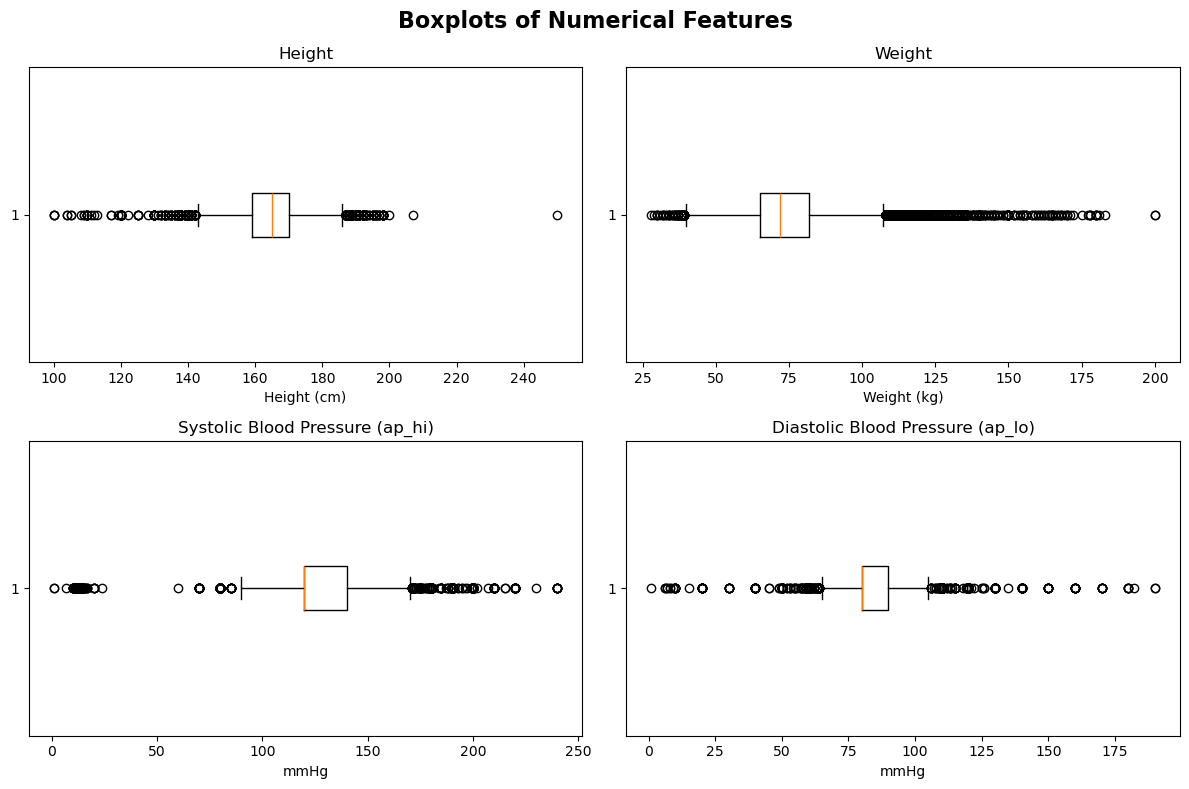

In [31]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Height
axes[0, 0].boxplot(df["height"], vert=False)
axes[0, 0].set_title("Height")
axes[0, 0].set_xlabel("Height (cm)")

# Weight
axes[0, 1].boxplot(df["weight"], vert=False)
axes[0, 1].set_title("Weight")
axes[0, 1].set_xlabel("Weight (kg)")

# Systolic Blood Pressure
axes[1, 0].boxplot(df["ap_hi"], vert=False)
axes[1, 0].set_title("Systolic Blood Pressure (ap_hi)")
axes[1, 0].set_xlabel("mmHg")

# Diastolic Blood Pressure
axes[1, 1].boxplot(df["ap_lo"], vert=False)
axes[1, 1].set_title("Diastolic Blood Pressure (ap_lo)")
axes[1, 1].set_xlabel("mmHg")

plt.suptitle("Boxplots of Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

##  Observations from the Boxplots

- **Height:** Most individuals have a height between **155 cm and 170 cm**. A few observations below **100 cm** and above **200 cm** appear as outliers, indicating extremely short or tall individuals.

- **Weight:** The majority of weight values lie between **65 kg and 80 kg**. Several observations above **110 kg** and a few below **40 kg** are detected as outliers.

- **Systolic Blood Pressure (ap_hi):** Most systolic blood pressure values are concentrated between **120 mmHg and 140 mmHg**. However, several unusually low and high values are present, which appear as outliers.

- **Diastolic Blood Pressure (ap_lo):** Most diastolic blood pressure values fall between **80 mmHg and 90 mmHg**. A small number of extremely low and high values are identified as outliers.


There are no such has large number of outiers, so it can be used.

# EDA (Expolatory Data Analysis)

### Cardio

cardio
0    35021
1    34979
Name: count, dtype: int64


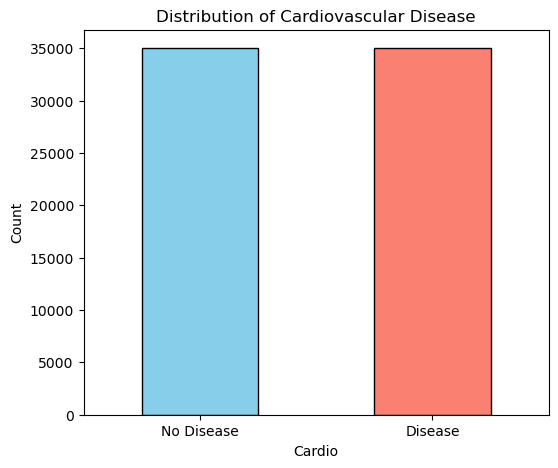

In [32]:
plt.figure(figsize=(6,5))
df["cardio"].value_counts().plot(
    kind="bar",
    color=["skyblue","salmon"],
    edgecolor="black"
)
plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("Count")
plt.xticks([0,1],["No Disease","Disease"], rotation=0);
data1=df['cardio'].value_counts()
print(data1)

- In the dataset there are 35021 No Disease and 34979 Dicease persons.so it can be say that results are equaly distributed

### Age

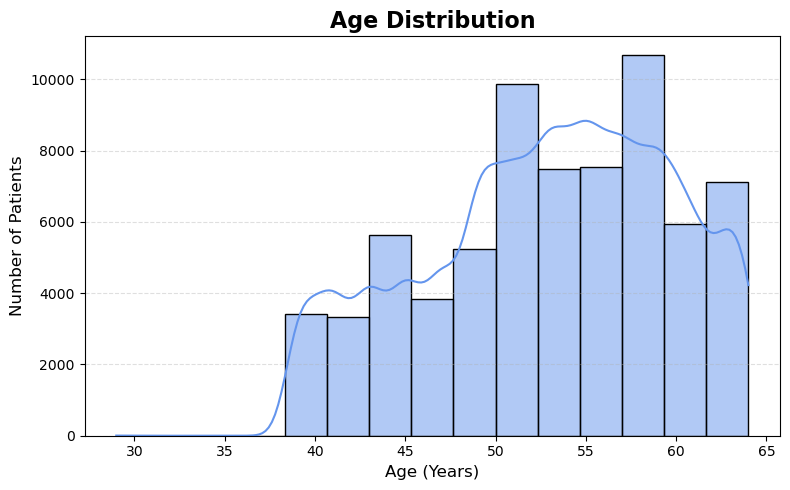

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="age",
    bins=15,
    kde=True,
    color="cornflowerblue",
    edgecolor="black"
)
plt.title("Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

The data of age is mostly disributed between 50-65 Years , and it is also showing highly normal distribution of data.

### Weight

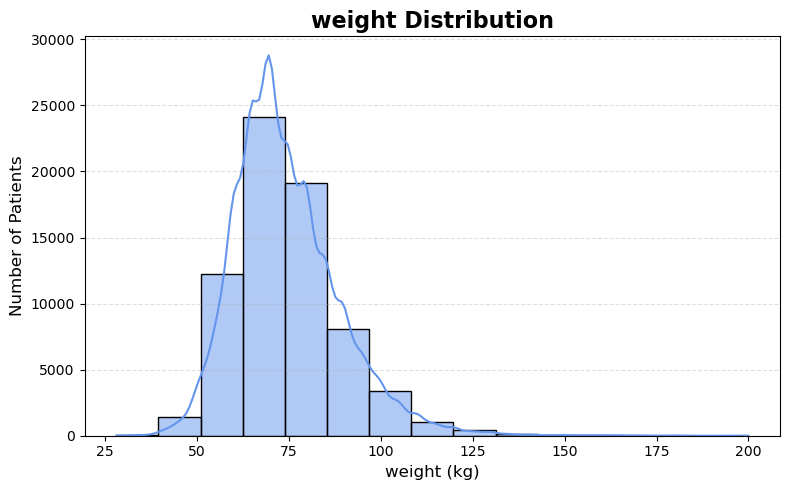

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="weight",
    bins=15,
    kde=True,
    color="cornflowerblue",
    edgecolor="black"
)
plt.title("weight Distribution", fontsize=16, fontweight="bold")
plt.xlabel("weight (kg)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

According to this plot it can be see that the data of weight is bell shaped, the mostly data is distributed between 30 and 100, there are only few data points are near to 200

### api_hi

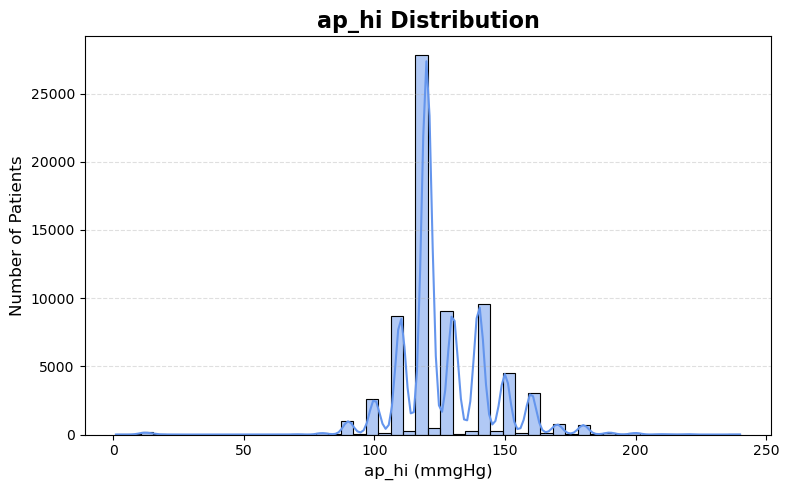

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="ap_hi",
    bins=50,
    kde=True,
    color="cornflowerblue",
    edgecolor="black"
)
plt.title("ap_hi Distribution", fontsize=16, fontweight="bold")
plt.xlabel("ap_hi (mmgHg)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

The ap_hi distribution chart reveals that the vast majority of patients are sharply clustered at a dominant peak of exactly 120 mmHg, representing well over 25,000 individuals. Beyond this main spike, the bulk of the remaining population falls within a broader, multi-modal clinical range spanning from 110 to 150 mmHg.

### Gender 

gender
1    45530
2    24470
Name: count, dtype: int64


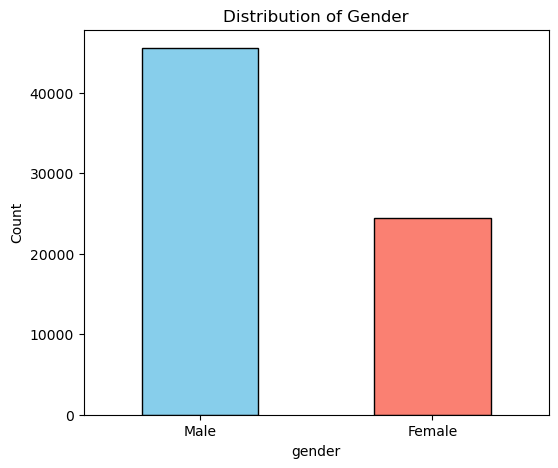

In [36]:
plt.figure(figsize=(6,5))
df["gender"].value_counts().plot(
    kind="bar",
    color=["skyblue","salmon"],
    edgecolor="black"
)
plt.title("Distribution of Gender")
plt.xlabel("gender")
plt.ylabel("Count")
plt.xticks([0,1],["Male","Female"], rotation=0);
data1=df['gender'].value_counts()
print(data1)

The Distribution of Gender chart shows that male participants heavily outnumber female participants in this dataset, with the male count peaking near 45,000. In contrast, the female category records a significantly lower count, sitting just below 25,000 individuals. This clear imbalance indicates a nearly 2:1 ratio.

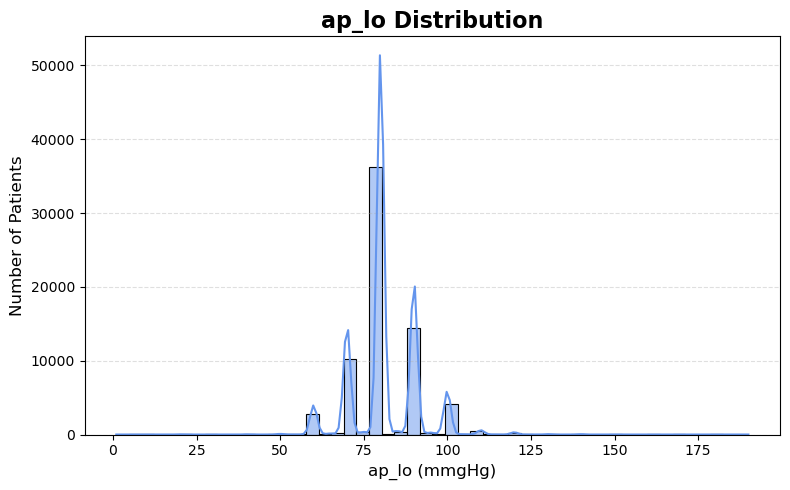

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="ap_lo",
    bins=50,
    kde=True,
    color="cornflowerblue",
    edgecolor="black"
)
plt.title("ap_lo Distribution", fontsize=16, fontweight="bold")
plt.xlabel("ap_lo (mmgHg)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

The ap_lo distribution chart reveals three primary insights about the dataset's patient population. First, there is a dominant and sharp peak centered exactly around 80 mmHg, representing the vast majority of individuals with well over 35,000 patients clustered at this value. Second, the bulk of the remaining data is concentrated within a multi-modal clinical range spanning from 60 to 100 mmHg, showing clear peaks at regular intervals like 70 and 90 mmHg.

### Cholesterol

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64


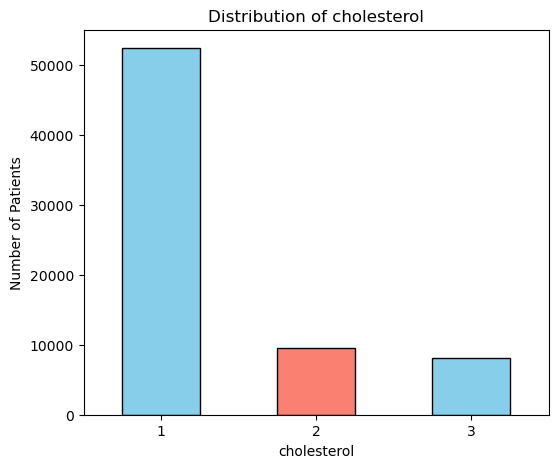

In [38]:
plt.figure(figsize=(6,5))
df["cholesterol"].value_counts().plot(
    kind="bar",
    color=["skyblue","salmon"],
    edgecolor="black"
)
plt.title("Distribution of cholesterol")
plt.xlabel("cholesterol")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0);
data1=df['cholesterol'].value_counts()
print(data1)

The Distribution of cholesterol chart shows a severe class imbalance, where category 1 heavily dominates the dataset with a count exceeding 50,000 individuals. In stark contrast, categories 2 and 3 have significantly lower representations, each registering under 10,000 counts. This steep decline indicates that the vast majority of patients fall into the first category.

### Glucose

gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64


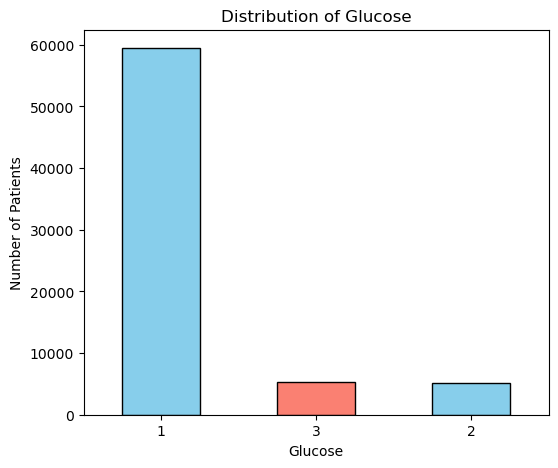

In [39]:
plt.figure(figsize=(6,5))
df["gluc"].value_counts().plot(
    kind="bar",
    color=["skyblue","salmon"],
    edgecolor="black"
)
plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0);
data1=df['gluc'].value_counts()
print(data1)

The Distribution of Glucose chart reveals an extreme class imbalance, where category 1 heavily dominates the dataset with a count nearing 60,000 individuals. In sharp contrast, categories 3 and 2 have minimal representation, with both categories hovering around just 5,000 counts each. This massive disparity shows that the overwhelming majority of the patient population falls into the first glucose category.

### Smoke

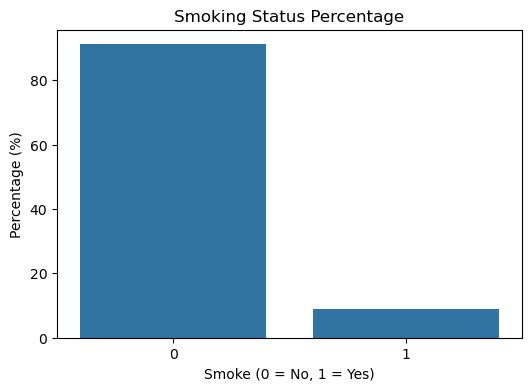

In [40]:
plt.figure(figsize=(6,4))
smoke_percent = df["smoke"].value_counts(normalize=True) * 100
sns.barplot(
    x=smoke_percent.index,
    y=smoke_percent.values
)
plt.title("Smoking Status Percentage")
plt.xlabel("Smoke (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.show()

The Distribution of smoke chart shows a significant imbalance in the dataset, where category 0 (non-smokers) overwhelmingly outnumbers category 1 (smokers) with a count exceeding 60,000 patients. In contrast, the smoking category has a much lower representation, recording just over 5,000 individuals. 

### Alcohol

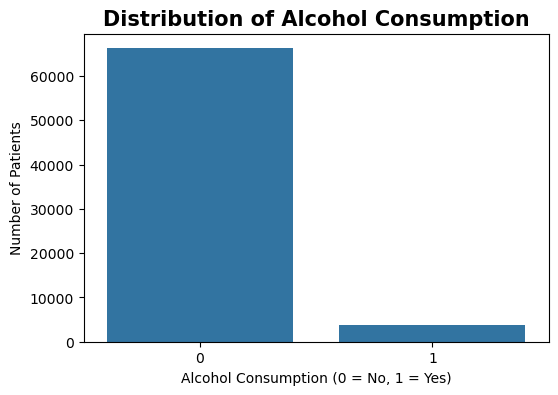

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="alco"
)
plt.title("Distribution of Alcohol Consumption", fontsize=15, fontweight="bold")
plt.xlabel("Alcohol Consumption (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

The Distribution of Alcohol Consumption chart reveals a major class imbalance in the dataset, where category 0 (patients who do not consume alcohol) heavily dominates with a count of over 65,000. Conversely, category 1 (patients who consume alcohol) shows a very low representation, hovering under 5,000 individuals. 

### Age vs Cardio

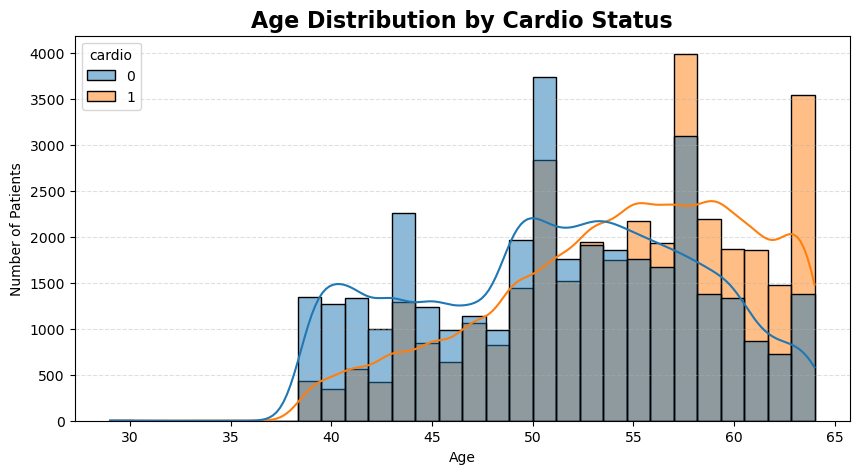

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="age",
    hue="cardio",
    kde=True,
    bins=30,
    alpha=0.5
)

plt.title("Age Distribution by Cardio Status", fontsize=16, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Age Distribution by Cardio Status chart reveals a clear relationship between advancing age and the risk of cardiovascular disease. In the younger demographic between 38 and 48 years old, patients without cardiovascular disease (cardio = 0, blue line) significantly outnumber those with the condition (cardio = 1, orange line). However, as age increases, the two trend lines cross near age 49, after which the presence of cardiovascular disease climbs steeply and consistently dominates the patient count, showing major orange peaks around ages 57 and 64.

### Gender vs Cardio

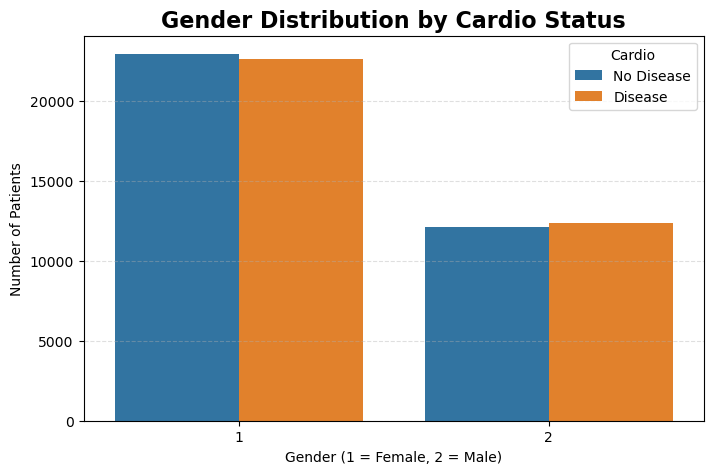

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="gender",
    hue="cardio"
)

plt.title("Gender Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Gender (1 = Female, 2 = Male)")
plt.ylabel("Number of Patients")

plt.legend(title="Cardio",
           labels=["No Disease", "Disease"])

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Gender Distribution by Cardio Status chart demonstrates a highly balanced distribution of cardiovascular disease within each gender group despite the baseline sample size differences. For Gender 1 (Female), the number of patients with "No Disease" (blue bar) and "Disease" (orange bar) are nearly identical, both hovering just above 22,500. Similarly, for Gender 2 (Male), the distribution remains tightly matched, with both bars sitting right around the 12,000 to 12,500 patient mark. 

### Height vs Cardio

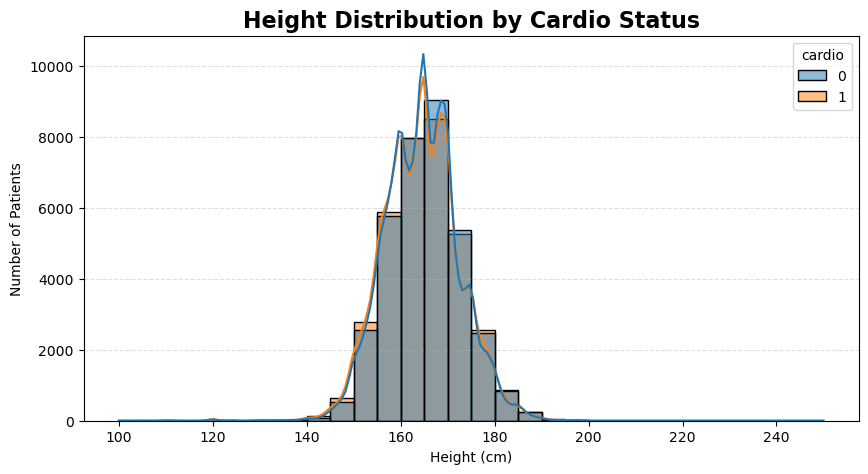

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="height",
    hue="cardio",
    kde=True,
    bins=30,
    alpha=0.5
)

plt.title("Height Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Height (cm)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Height Distribution by Cardio Status chart demonstrates a near-identical distribution between patients with and without cardiovascular disease across different heights. Both the blue curve (cardio = 0) and the orange curve (cardio = 1) track each other almost perfectly, peaking heavily between 160 cm and 170 cm. 

### Weight vs Cardio

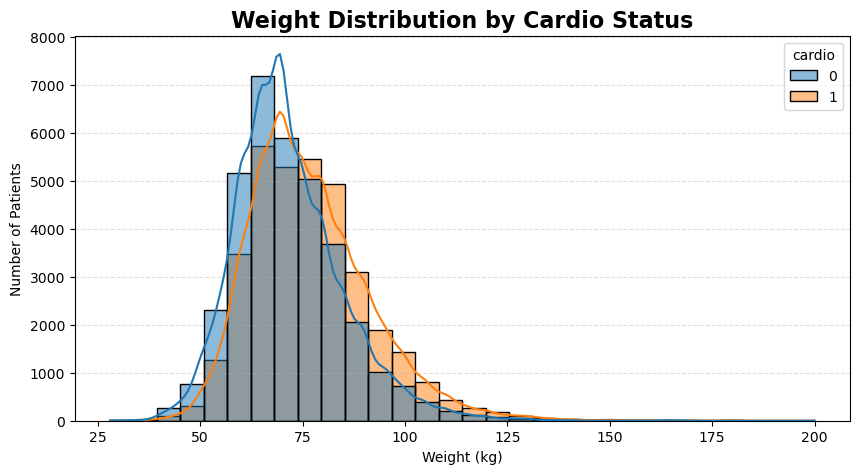

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="weight",
    hue="cardio",
    kde=True,
    bins=30,
    alpha=0.5
)

plt.title("Weight Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Weight (kg)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Weight Distribution by Cardio Status chart highlights a visible shift toward higher body weights for patients diagnosed with cardiovascular disease. In the lower weight range between 50 kg and 70 kg, patients without the disease (cardio = 0, blue line) noticeably outnumber those with it, peaking strongly near 65 kg. However, from 75 kg up to 125 kg, the distribution shifts significantly as the orange line (cardio = 1) consistently stays above the blue line, demonstrating that the presence of cardiovascular disease becomes more prevalent as patient weight increases.

### Ap_hi (Systolic Blood Pressure) vs Cardio

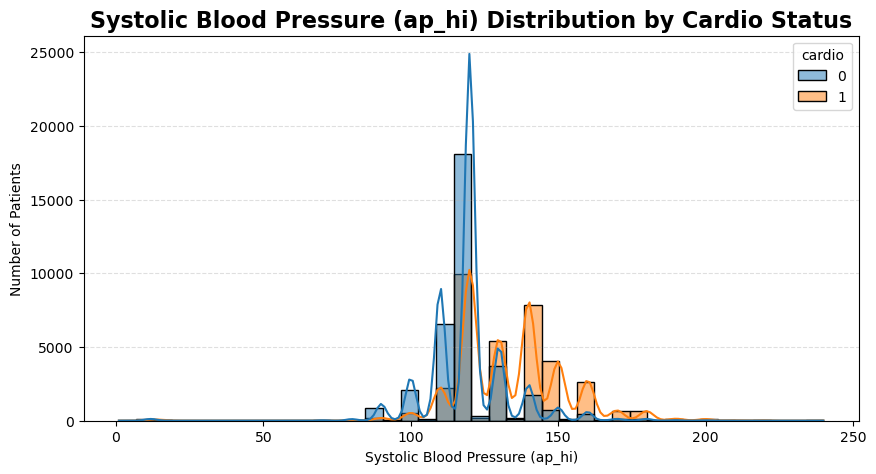

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="ap_hi",
    hue="cardio",
    kde=True,
    bins=40,
    alpha=0.5
)

plt.title("Systolic Blood Pressure (ap_hi) Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Systolic Blood Pressure (ap_hi)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Systolic Blood Pressure (ap_hi) Distribution by Cardio Status chart shows a very strong separation between patients based on their cardiovascular health. At the healthy threshold of 120 mmHg, patients without cardiovascular disease (cardio = 0, blue line) overwhelmingly dominate the dataset with a sharp, massive peak of 25,000 individuals. Conversely, as systolic pressure increases into hypertensive ranges from 130 mmHg to 160 mmHg, the distribution shifts dramatically, with patients diagnosed with cardiovascular disease (cardio = 1, orange line) heavily outnumbering healthy individuals at every peak.

### Ap_LO (Systolic Blood Pressure) vs Cardio

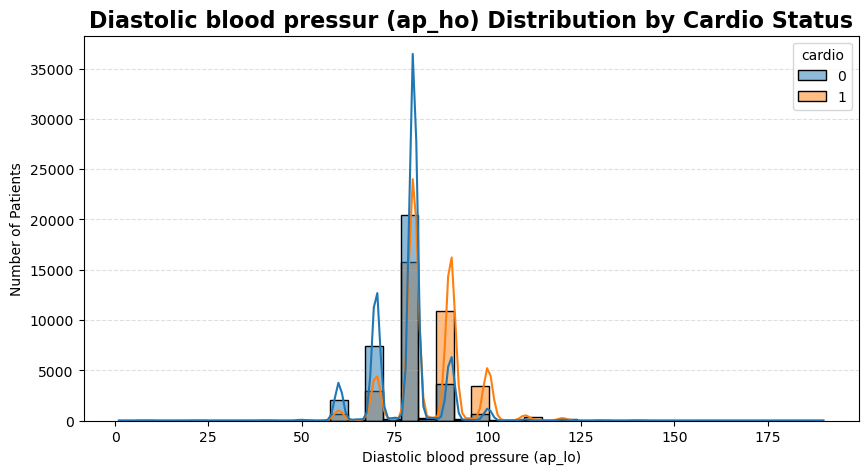

In [47]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="ap_lo",
    hue="cardio",
    kde=True,
    bins=40,
    alpha=0.5
)

plt.title("Diastolic blood pressur (ap_ho) Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Diastolic blood pressure (ap_lo)")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Systolic Blood Pressure (ap_hi) Distribution by Cardio Status chart shows a very strong separation between patients based on their cardiovascular health. At the healthy threshold of 120 mmHg, patients without cardiovascular disease (cardio = 0, blue line) overwhelmingly dominate the dataset with a sharp, massive peak of 25,000 individuals. Conversely, as systolic pressure increases into hypertensive ranges from 130 mmHg to 160 mmHg, the distribution shifts dramatically, with patients diagnosed with cardiovascular disease (cardio = 1, orange line) heavily outnumbering healthy individuals at every peak

### Cholesterol vs Cardio

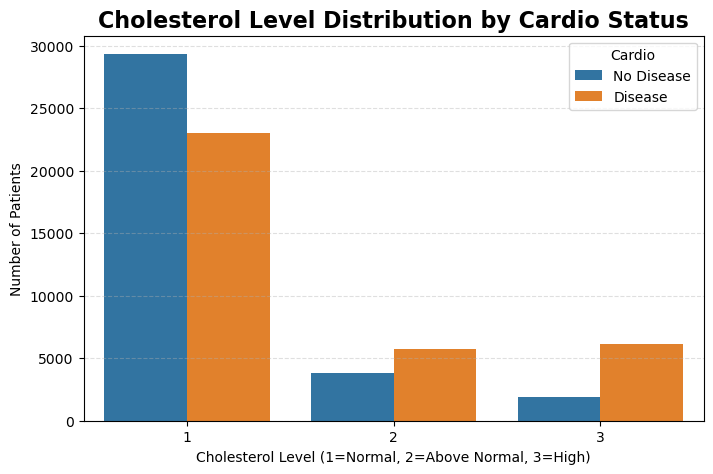

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="cholesterol",
    hue="cardio"
)

plt.title("Cholesterol Level Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Cholesterol Level (1=Normal, 2=Above Normal, 3=High)")
plt.ylabel("Number of Patients")

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Cholesterol Level Distribution by Cardio Status chart highlights a clear correlation between elevated cholesterol levels and the prevalence of cardiovascular disease. For patients with category 1 (Normal) cholesterol, healthy individuals (blue bar, ~29,000) noticeably outnumber those with the disease (orange bar, ~23,000). However, this trend completely flips in categories 2 (Above Normal) and 3 (High).

### Glucose (gluc) vs Cardio

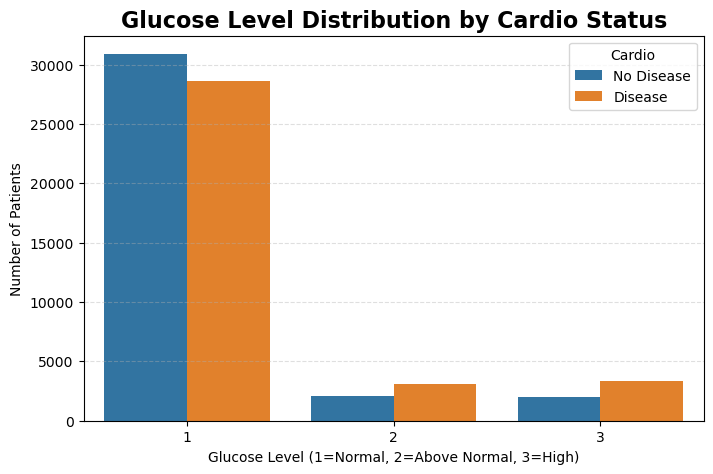

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="gluc",
    hue="cardio"
)

plt.title("Glucose Level Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Glucose Level (1=Normal, 2=Above Normal, 3=High)")
plt.ylabel("Number of Patients")

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Glucose Level Distribution by Cardio Status chart demonstrates a positive correlation between elevated glucose levels and the presence of cardiovascular disease. Among patients with category 1 (Normal) glucose levels, healthy individuals (blue bar, ~31,000) outnumber those with the disease (orange bar, ~28,500). Conversely, for categories 2 (Above Normal) and 3 (High), the trend reverses as patients diagnosed with cardiovascular disease noticeably outnumber healthy individuals in both elevated categories.

### Smoke (smoke) vs Cardio

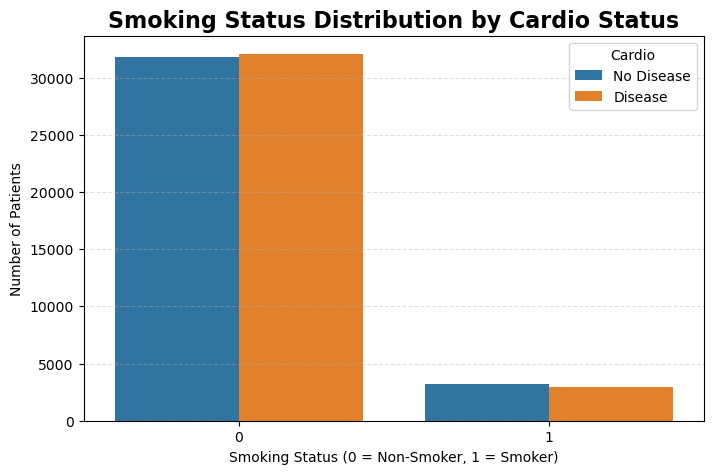

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="smoke",
    hue="cardio"
)

plt.title("Smoking Status Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Smoking Status (0 = Non-Smoker, 1 = Smoker)")
plt.ylabel("Number of Patients")

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Smoking Status Distribution by Cardio Status chart shows a highly balanced split of cardiovascular disease within both smoking and non-smoking groups. For category 0 (Non-Smokers), the counts for "No Disease" (blue bar) and "Disease" (orange bar) are nearly identical, both hovering right around the 32,000 patient mark. Similarly, for category 1 (Smokers), the distribution remains tightly balanced with both bars sitting closely around 3,000 patients.

### Alcohol (alco) vs Cardio

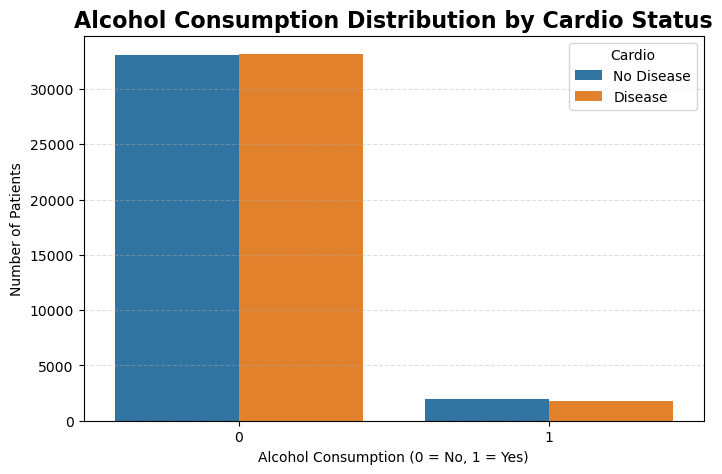

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="alco",
    hue="cardio"
)

plt.title("Alcohol Consumption Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Alcohol Consumption (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Alcohol Consumption Distribution by Cardio Status chart shows a highly balanced ratio of cardiovascular disease across both consumer groups. In category 0 (No), representing non-drinkers, the counts for "No Disease" (blue bar) and "Disease" (orange bar) are nearly identical, both peaking right around 33,000 patients. Similarly, for category 1 (Yes), representing alcohol consumers, the distribution remains evenly matched with both bars sitting closely near the 2,000 patient mark

### Active (active) vs Cardio

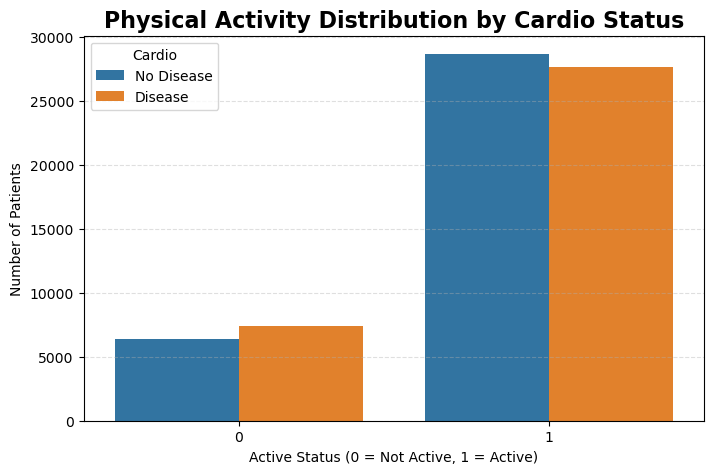

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="active",
    hue="cardio"
)

plt.title("Physical Activity Distribution by Cardio Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Active Status (0 = Not Active, 1 = Active)")
plt.ylabel("Number of Patients")

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The Physical Activity Distribution by Cardio Status chart indicates a protective correlation between physical activity and cardiovascular health. In category 0 (Not Active), patients diagnosed with cardiovascular disease (orange bar, ~7,500) outnumber healthy individuals (blue bar, ~6,400). Conversely, in category 1 (Active).

### Feature Relationship Analysis

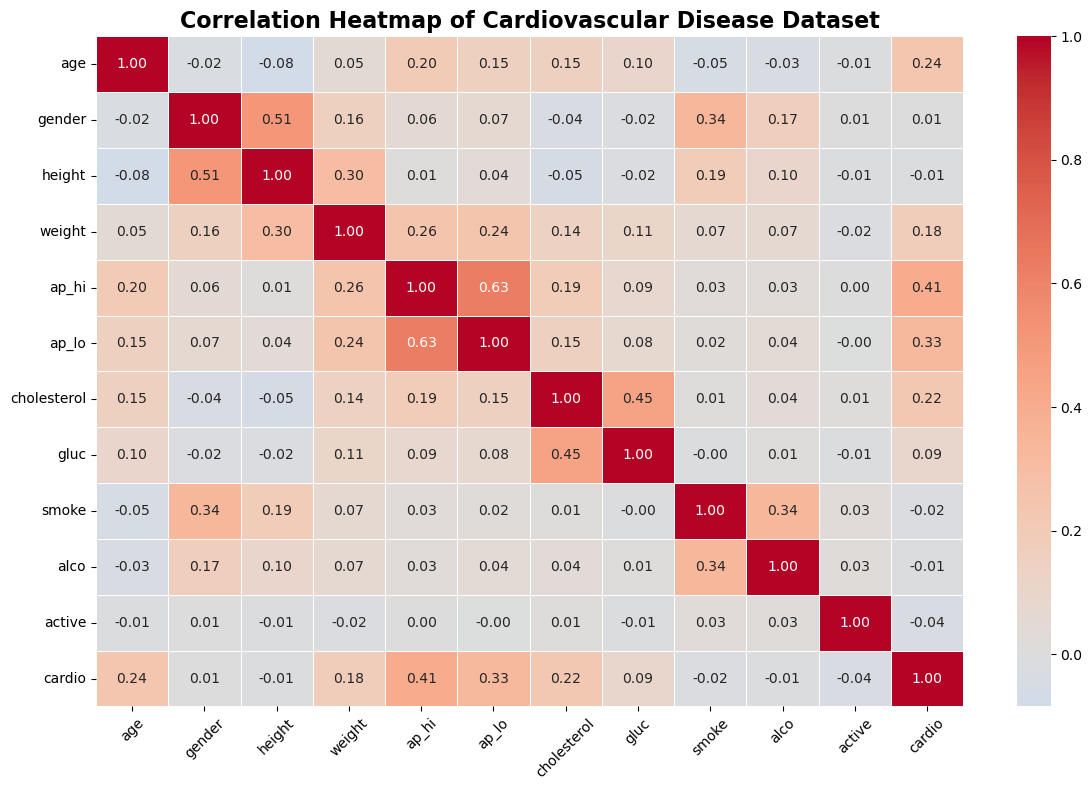

In [53]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Heatmap of Cardiovascular Disease Dataset",
          fontsize=16,
          fontweight="bold")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

The Correlation Heatmap of Cardiovascular Disease Dataset provides several critical insights into how the dataset's features interact with each other and with the target variable (cardio):
- Strongest Predictors of Disease: Systolic blood pressure (ap_hi, 0.41) and diastolic blood pressure (ap_lo, 0.33) show the strongest positive correlations with cardiovascular disease (cardio), followed closely by age (0.24) and cholesterol (0.22).

- High Feature Intercorrelation (Collinearity): There is a strong relationship between blood pressure features (ap_hi and ap_lo at 0.63), biological metrics (gender and height at 0.51), and metabolic indicators (cholesterol and gluc at 0.45).

- Negligible Correlates: Physical lifestyle metrics like being active (-0.04), smoke (-0.02), and alco (-0.01) display near-zero linear correlation with the final cardiovascular status in this dataset.

# Model Creation

### Separate features and target


In [54]:

X = df.drop("cardio", axis=1)

y = df["cardio"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (70000, 11)
Target Shape: (70000,)


### Train-Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (56000, 11)
Testing Data: (14000, 11)


### Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [57]:
from sklearn.neighbors import KNeighborsClassifier

### Create and Train KNN Model

In [65]:
# Create KNN model

knn = KNeighborsClassifier(
    n_neighbors=21
)

# Train the model

knn.fit(
    X_train_scaled,
    y_train
)


KNeighborsClassifier(n_neighbors=21)

### Make Predictions

In [66]:
y_pred = knn.predict(X_test_scaled)

print(y_pred[:10])

[0 1 0 0 0 0 0 0 0 1]


# Model Evaluation`

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Accuracy

In [68]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.7207857142857143


### Performance Report

In [69]:
print("KNN Classification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred
    )
)

KNN Classification Report
-------------------------
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      7004
           1       0.74      0.69      0.71      6996

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000



### Confusion Matrix

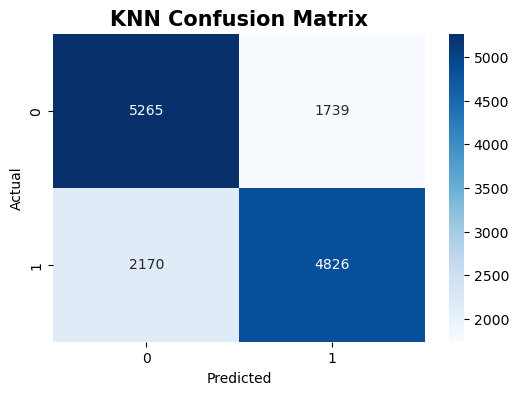

In [70]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("KNN Confusion Matrix",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Find Best Value of K

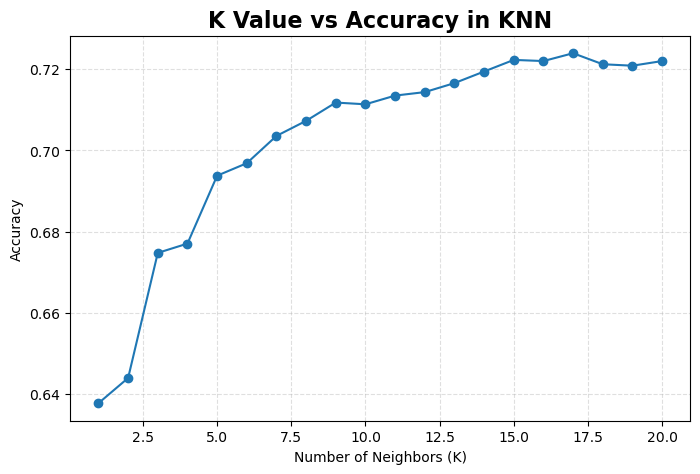

In [71]:
accuracy_scores = []

for k in range(1,21):
    
    knn_model = KNeighborsClassifier(
        n_neighbors=k
    )
    
    knn_model.fit(
        X_train_scaled,
        y_train
    )
    
    pred = knn_model.predict(
        X_test_scaled
    )
    
    accuracy_scores.append(
        accuracy_score(y_test, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,21),
    accuracy_scores,
    marker="o"
)

plt.title("K Value vs Accuracy in KNN",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.show()


## K Value 

- Different values of K were tested to find the optimal number of neighbors for the KNN model.
- The accuracy increased as the value of K increased, showing better generalization with more neighbors.
- The model achieved the highest accuracy around **K = 17**, with an accuracy of approximately **72%**.
- Very small values of K (such as K=1 or K=2) showed lower accuracy because the model was more sensitive to individual data points.
- After K=15, the accuracy became almost stable, indicating that increasing K further does not significantly improve performance.
- Therefore, **K=17 can be considered the best choice for this dataset based on accuracy performance.**

## Analysis Summary

This project focused on predicting cardiovascular disease using patient health and lifestyle information. Exploratory Data Analysis (EDA) was performed to understand the relationship between different features and the target variable (`cardio`).

### Key Findings:

- **Age:** Older patients showed a higher occurrence of cardiovascular disease, indicating that age is an important risk factor.
- **Gender:** Cardiovascular disease was observed in both genders, but gender alone did not show a strong relationship with the target.
- **Height & Weight:** Height had a weak relationship with cardiovascular disease, while higher weight showed a slightly increased risk. BMI-based analysis could provide better insights.
- **Blood Pressure (`ap_hi` and `ap_lo`):** Both systolic and diastolic blood pressure showed a positive relationship with cardiovascular disease. Patients with higher blood pressure values were more likely to have heart disease.
- **Cholesterol:** Higher cholesterol levels were associated with increased cardiovascular disease risk.
- **Glucose:** Abnormal glucose levels showed a slightly higher occurrence of cardiovascular disease.
- **Lifestyle Factors:**
  - Smoking, alcohol consumption, and physical activity showed weaker individual relationships with cardiovascular disease.
  - These factors may become more meaningful when combined with medical features.

### Correlation Analysis:

- Features like **age, systolic blood pressure, diastolic blood pressure, cholesterol, and glucose** showed positive correlation with the target variable.
- No single feature was highly correlated with cardiovascular disease, indicating that multiple factors contribute together.

### Model Implementation:

- K-Nearest Neighbors (KNN) was implemented for cardiovascular disease prediction.
- Feature scaling was applied because KNN depends on distance calculations.
- The model performance was evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

### KNN Model Performance Conclusion

The KNN model was optimized by testing different values of K. The accuracy curve showed that the model performance improved gradually with increasing neighbors and reached the best performance at approximately **K=17**. After this point, accuracy remained nearly constant, indicating that the model had reached a stable performance level.

The optimized KNN model provides a reasonable prediction capability for cardiovascular disease classification. However, because cardiovascular disease depends on multiple complex medical factors, other classification models can also be tested and compared to identify the best-performing approach.